In [51]:
import time
import tracemalloc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.neighbors import NearestNeighbors

In [52]:
df = pd.read_csv('../data/komdigi_hoaks.csv')

df['teks'] = df['title'].fillna('') + ' ' + df['excerpt'].fillna('')
df = df[df['teks'].str.strip() != ''].reset_index(drop=True)

print(f"Total data bersih siap klasterisasi: {len(df)} baris")
df[['title', 'teks']].head()

Total data bersih siap klasterisasi: 4176 baris


,title,teks
0,[HOAKS] Tautan Pencairan BSU September 2026 Se...,[HOAKS] Tautan Pencairan BSU September 2026 Se...
1,[HOAKS] Panas El Nino Berkaitan dengan Gelomba...,[HOAKS] Panas El Nino Berkaitan dengan Gelomba...
2,[HOAKS] Susu Bebelac Berbahaya karena Mengandu...,[HOAKS] Susu Bebelac Berbahaya karena Mengandu...
3,[HOAKS] Purbaya Informasikan Raffi Ahmad Beli ...,[HOAKS] Purbaya Informasikan Raffi Ahmad Beli ...
4,[HOAKS] Tautan Bantuan Laptop dan Ponsel untuk...,[HOAKS] Tautan Bantuan Laptop dan Ponsel untuk...


In [53]:
tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(df['teks'])

print("Bentuk matriks data:", X.shape)

Bentuk matriks data: (4176, 1000)


In [54]:
nn = NearestNeighbors(n_neighbors=10, metric='euclidean')
nn.fit(X)
distances, _ = nn.kneighbors(X)

k_distances = np.sort(distances[:, -1])
eps_otomatis = float(np.percentile(k_distances, 75))
print(f'Nilai eps otomatis: {eps_otomatis:.4f}')

Nilai eps otomatis: 1.1713


In [55]:
# Mulai pelacakan memori & waktu
tracemalloc.start()
waktu_mulai = time.time()

dbscan_euclidean = DBSCAN(eps=eps_otomatis, min_samples=10, metric='euclidean')
df['cluster_dbscan_euclidean'] = dbscan_euclidean.fit_predict(X)

waktu_selesai = time.time()
mem_sekarang, mem_puncak = tracemalloc.get_traced_memory()
tracemalloc.stop()

labels = df['cluster_dbscan_euclidean']
hasil_jumlah_klaster = len(set(labels)) - (1 if -1 in labels else 0)
jumlah_noise = (labels == -1).sum()

hasil_waktu = waktu_selesai - waktu_mulai
hasil_memori_mb = mem_puncak / (1024 * 1024)

if hasil_jumlah_klaster > 1:
    hasil_silhouette = metrics.silhouette_score(X, labels, metric='euclidean')
else:
    hasil_silhouette = 0.0

print("=" * 45)
print("HASIL PENGUJIAN: DBSCAN JARAK EUCLIDEAN")
print("=" * 45)
print(f"1. Jumlah Klaster   : {hasil_jumlah_klaster} klaster (dan {jumlah_noise} data noise)")
print(f"2. Waktu Eksekusi    : {hasil_waktu:.4f} detik")
print(f"3. Silhouette Score : {hasil_silhouette:.4f} (metrik euclidean)")
print(f"4. Penggunaan Memori: {hasil_memori_mb:.2f} MB")
print("=" * 45)

HASIL PENGUJIAN: DBSCAN JARAK EUCLIDEAN
1. Jumlah Klaster   : 2 klaster (dan 59 data noise)
2. Waktu Eksekusi    : 0.1886 detik
3. Silhouette Score : 0.0022 (metrik euclidean)
4. Penggunaan Memori: 266.86 MB


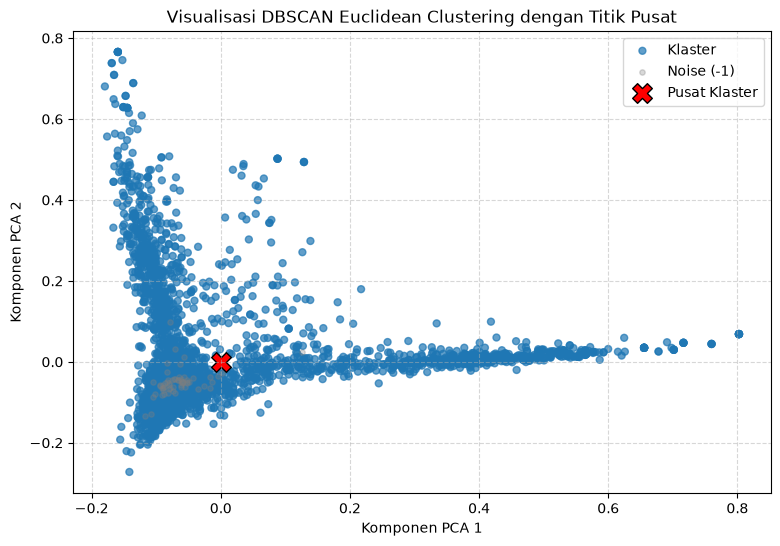

In [56]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

plt.figure(figsize=(9, 6))

non_noise = df[df['cluster_dbscan_euclidean'] != -1]
plt.scatter(
    non_noise['pca1'],
    non_noise['pca2'],
    c=non_noise['cluster_dbscan_euclidean'],
    cmap='tab10',
    s=25,
    alpha=0.7,
    label='Klaster',
)

noise = df[df['cluster_dbscan_euclidean'] == -1]
plt.scatter(
    noise['pca1'],
    noise['pca2'],
    color='gray',
    s=15,
    alpha=0.3,
    label='Noise (-1)',
)

for i, c in enumerate(sorted(non_noise['cluster_dbscan_euclidean'].unique())):
  pusat_x = non_noise[non_noise['cluster_dbscan_euclidean'] == c]['pca1'].mean()
  pusat_y = non_noise[non_noise['cluster_dbscan_euclidean'] == c]['pca2'].mean()
  plt.scatter(
      pusat_x,
      pusat_y,
      marker='X',
      s=200,
      color='red',
      edgecolors='black',
      label='Pusat Klaster' if i == 0 else '',
  )

plt.title('Visualisasi DBSCAN Euclidean Clustering dengan Titik Pusat')
plt.xlabel('Komponen PCA 1')
plt.ylabel('Komponen PCA 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [57]:
terms = tfidf.get_feature_names_out()
unique_clusters = sorted(df['cluster_dbscan_euclidean'].unique())

print("Kata Kunci Dominan Tiap Klaster DBSCAN:")
for c in unique_clusters:
    if c == -1:
        nama = "NOISE / OUTLIER"
    else:
        nama = f"Klaster {c}"
    
    idx = df[df['cluster_dbscan_euclidean'] == c].index
    mean_tfidf = np.asarray(X[idx].mean(axis=0)).flatten()
    top_terms = [terms[i] for i in mean_tfidf.argsort()[::-1][:7]]
    print(f"[{nama}] ({len(idx)} data): {', '.join(top_terms)}")

Kata Kunci Dominan Tiap Klaster DBSCAN:
[NOISE / OUTLIER] (59 data): yang, tidak, dan, hoaks, tersebut, di, bahwa
[Klaster 0] (4117 data): hoaks, mengatasnamakan, akun, di, whatsapp, tautan, dan
